In [1]:
# 기본 라이브러리
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False
import gc
plt.rc('font', family='NanumBarunGothic')

# 인코더 추가
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
#VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
#상수항추가
from statsmodels.tools.tools import add_constant
# 카이제곱, ANOVA
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway
#Turkeyhsd
from statsmodels.stats.multicomp import pairwise_tukeyhsd# 기본 라이브러리
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import gc

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [2]:
# 코랩 한국어
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

### 데이터 불러오기

In [3]:
# parquet 파일 데이터를 읽어온다.

all_df = pd.read_parquet('/content/drive/MyDrive/뺄거다빼고세그먼트넣고데이터타입바꿈.parquet')


In [4]:
# 데이터프레임의 컬럼 이름을 리스트에 담는다.
column_list = all_df.columns.tolist()

In [5]:
print(column_list)

['기준년월', 'ID', '소지카드수_이용가능_신용', '소지카드수_유효_신용', '이용가능여부_해외겸용_본인', '보유여부_해외겸용_본인', '수신거부여부_TM', '수신거부여부_메일', '수신거부여부_DM', '이용금액_R3M_신용체크', '이용금액_R3M_신용', '_1순위카드이용금액', '이용카드수_신용체크', '_2순위카드이용금액', '_1순위카드이용건수', '_2순위카드이용건수', '이용카드수_신용', '상향가능한도금액', '상향가능CA한도금액', '정상청구원금_B5M', '정상청구원금_B0M', '정상청구원금_B2M', '이용금액_일시불_R12M', '이용금액_일시불_B0M', '이용금액_오프라인_B0M', '이용금액_일시불_R6M', '이용금액_일시불_R3M', '정상입금원금_B5M', '정상입금원금_B0M', '이용금액_오프라인_R3M', '이용금액_오프라인_R6M', '정상입금원금_B2M', '_3순위업종_이용금액', '_2순위업종_이용금액', '이용건수_신용_R12M', '_2순위쇼핑업종_이용금액', '최대이용금액_일시불_R12M', '이용건수_신판_R12M', '이용건수_일시불_R12M', '_1순위업종_이용금액', '_3순위쇼핑업종_이용금액', '이용가맹점수', '이용건수_오프라인_B0M', '이용건수_오프라인_R6M', '이용건수_오프라인_R3M', '쇼핑_도소매_이용금액', '이용건수_신용_R6M', '이용건수_신용_B0M', '이용건수_신용_R3M', '이용건수_신판_R6M', '이용건수_신판_B0M', '이용건수_신판_R3M', '이용건수_일시불_R6M', '이용건수_일시불_B0M', '이용건수_일시불_R3M', '_1순위교통업종_이용금액', '연체입금원금_B0M', '쇼핑_마트_이용금액', '쇼핑_슈퍼마켓_이용금액', '교통_주유이용금액', '이용금액_온라인_B0M', '연체입금원금_B5M', '연체입금원금_B2M', '이용금액_페이_온라인_B0M', '_1순위쇼핑업종_이용금액', '연속유실적개월수_기본_24M_카드', '이용

In [6]:
# 데이터타입을 확인해본다
all_df.dtypes

,0
기준년월,int32
ID,object
소지카드수_이용가능_신용,int32
소지카드수_유효_신용,int32
이용가능여부_해외겸용_본인,int32
...,...
잔액_일시불_B0M,int32
잔액_일시불_B1M,int32
잔액_일시불_B2M,int32
인입횟수_ARS_R6M,object


In [7]:
10/0

ZeroDivisionError: division by zero

### 세그먼트별로 나눈 데이터

In [ ]:
a_ids = all_df[all_df['Segment'] == 'A']['ID']
a_df = all_df[all_df['ID'].isin(a_ids)]
a_df

In [ ]:
b_ids = all_df[all_df['Segment'] == 'B']['ID']
b_df = all_df[all_df['ID'].isin(b_ids)]

In [ ]:
c_ids = all_df[all_df['Segment'] == 'C']['ID']
c_df = all_df[all_df['ID'].isin(c_ids)]

In [ ]:
d_ids = all_df[all_df['Segment'] == 'D']['ID']
d_df = all_df[all_df['ID'].isin(d_ids)]

In [ ]:
e_ids = all_df[all_df['Segment'] == 'E']['ID']
e_df = all_df[all_df['ID'].isin(e_ids)]
e_df

### all_df를 월별로 구분해준다

In [ ]:
# all_df를 월별로 구분해준다
all_df07 = all_df.query('기준년월 == 201807')
all_df08 = all_df.query('기준년월 == 201808')
all_df09 = all_df.query('기준년월 == 201809')
all_df10 = all_df.query('기준년월 == 201810')
all_df11 = all_df.query('기준년월 == 201811')
all_df12 = all_df.query('기준년월 == 201812')

In [ ]:
all_df07

In [ ]:
# 기준년월로 나눈 데이터의 인덱스를 초기화한다.
all_df07 = all_df07.reset_index()
all_df08 = all_df08.reset_index()
all_df09 = all_df09.reset_index()
all_df10 = all_df10.reset_index()
all_df11 = all_df11.reset_index()
all_df12 = all_df12.reset_index()

In [ ]:
all_df08

In [ ]:
# all_df07과 all_df08에서 ID와 Segment만 추출
seg07 = all_df07[['ID', 'Segment']].rename(columns={'Segment': 'Segment_07'})
seg08 = all_df08[['ID', 'Segment']].rename(columns={'Segment': 'Segment_08'})

# ID 기준으로 병합
seg_change = pd.merge(seg07, seg08, on='ID', how='inner')

# 세그먼트가 다르면 1, 같으면 0
all_df08['세그먼트변화'] = (seg_change['Segment_07'] != seg_change['Segment_08']).astype(np.int8)

In [ ]:
all_df08

In [ ]:
all_df08.query('세그먼트변화 == 1')

In [ ]:
seg08 = all_df08[['ID', 'Segment']].rename(columns={'Segment': 'Segment_08'})
seg09 = all_df09[['ID', 'Segment']].rename(columns={'Segment': 'Segment_09'})

# ID 기준으로 병합
seg_change = pd.merge(seg08, seg09, on='ID', how='inner')

# 세그먼트가 다르면 1, 같으면 0
all_df09['세그먼트변화'] = (seg_change['Segment_08'] != seg_change['Segment_09']).astype(np.int8)

In [ ]:
all_df09.query('세그먼트변화 == 1')

In [ ]:
seg09 = all_df09[['ID', 'Segment']].rename(columns={'Segment': 'Segment_09'})
seg10 = all_df10[['ID', 'Segment']].rename(columns={'Segment': 'Segment_10'})
# ID 기준으로 병합
seg_change = pd.merge(seg09, seg10, on='ID', how='inner')

# 세그먼트가 다르면 1, 같으면 0
all_df10['세그먼트변화'] = (seg_change['Segment_09'] != seg_change['Segment_10']).astype(np.int8)

In [ ]:
all_df10.query('세그먼트변화 == 1')

In [ ]:
seg10 = all_df10[['ID', 'Segment']].rename(columns={'Segment': 'Segment_10'})
seg11 = all_df11[['ID', 'Segment']].rename(columns={'Segment': 'Segment_11'})
# ID 기준으로 병합
seg_change = pd.merge(seg10, seg11, on='ID', how='inner')

# 세그먼트가 다르면 1, 같으면 0
all_df11['세그먼트변화'] = (seg_change['Segment_10'] != seg_change['Segment_11']).astype(np.int8)

In [ ]:
all_df10.query('세그먼트변화 == 1')

In [ ]:
seg11 = all_df11[['ID', 'Segment']].rename(columns={'Segment': 'Segment_11'})
seg12 = all_df12[['ID', 'Segment']].rename(columns={'Segment': 'Segment_12'})
# ID 기준으로 병합
seg_change = pd.merge(seg11, seg12, on='ID', how='inner')

# 세그먼트가 다르면 1, 같으면 0
all_df12['세그먼트변화'] = (seg_change['Segment_11'] != seg_change['Segment_12']).astype(np.int8)

In [ ]:
all_df10.query('세그먼트변화 == 1')

고객의 세그먼트가 짧은 기간(6개월) 동안 거의 변하지 않았다.

현재 세그먼트 기준은 변별력이 낮거나 고정 속성이 반영된 것일 수 있다

단기보다는 6개월~1년 간 누적된 행동 특성으로 세그먼트를 정의하는 게 유리할 수 있다

### Kmeans

In [ ]:
features = [
    '정상청구원금_B5M', '정상청구원금_B0M', '정상청구원금_B2M',
    '이용금액_일시불_R12M', '이용금액_일시불_B0M', '이용금액_오프라인_B0M',
    '이용금액_일시불_R6M', '이용금액_일시불_R3M', '정상입금원금_B5M',
    '정상입금원금_B0M', '이용금액_오프라인_R3M', '이용금액_오프라인_R6M',
    '정상입금원금_B2M', '_3순위업종_이용금액', '_2순위업종_이용금액',
    '이용건수_신용_R12M', '_2순위쇼핑업종_이용금액', '최대이용금액_일시불_R12M',
    '이용건수_신판_R12M', '이용건수_일시불_R12M', '_1순위업종_이용금액',
    '_3순위쇼핑업종_이용금액', '이용가맹점수', '이용건수_오프라인_B0M',
    '이용건수_오프라인_R6M', '이용건수_오프라인_R3M', '쇼핑_도소매_이용금액',
    '이용건수_신용_R6M', '이용건수_신용_B0M', '이용건수_신용_R3M',
    '이용건수_신판_R6M', '이용건수_신판_B0M', '이용건수_신판_R3M',
    '이용건수_일시불_R6M', '이용건수_일시불_B0M', '이용건수_일시불_R3M',
    '_1순위교통업종_이용금액', '연체입금원금_B0M', '쇼핑_마트_이용금액',
    '쇼핑_슈퍼마켓_이용금액', '교통_주유이용금액', '이용금액_온라인_B0M',
    '연체입금원금_B5M', '연체입금원금_B2M', '이용금액_페이_온라인_B0M',
    '_1순위쇼핑업종_이용금액', '연속유실적개월수_기본_24M_카드'
]
print(len(features))

In [ ]:

# 1. 사용할 데이터 준비 (수치형 변수만 추출)
X = all_df07[features].copy()

# 결측치 제거
X = X.dropna()

# 2. 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. 최적 클러스터 수 찾기 (Elbow Method)
inertia = []
k_range = range(2, 11)
for k in k_range:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('n_Cluster (k)')
plt.ylabel('Inertia')
plt.grid()
plt.show()


In [ ]:
# k=4
k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
X['Cluster'] = kmeans.fit_predict(X_scaled)

# 클러스터별 프로파일링
profile = X.groupby('Cluster').mean()
print(profile)

# 시각화 (예: PCA를 활용한 2D 표현)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
X['PCA1'] = X_pca[:, 0]
X['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(8,6))
sns.scatterplot(data=X, x='PCA1', y='PCA2', hue='Cluster', palette='Set2')
plt.title('KMeans Clustering Results')

plt.show()


In [ ]:
# k=5
k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
X['Cluster'] = kmeans.fit_predict(X_scaled)

# 클러스터별 프로파일링
profile = X.groupby('Cluster').mean()
print(profile)

# 시각화 (예: PCA를 활용한 2D 표현)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
X['PCA1'] = X_pca[:, 0]
X['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(8,6))
sns.scatterplot(data=X, x='PCA1', y='PCA2', hue='Cluster', palette='Set2')
plt.title('KMeans Clustering Results')

plt.show()


In [ ]:
pd.set_option('display.max_columns', None)  # 모든 컬럼 출력
pd.set_option('display.width', None)        # 줄바꿈 없이 출력
print(profile)

In [ ]:
profile = X.groupby('Cluster').count()
print(profile)

In [ ]:
all_df07['Segment'].value_counts()

1,3번이 E, 0이 D, 4가 C, A와 B는 2어딘가에 있지 않을까

In [ ]:
pd.crosstab(X['Cluster'], all_df07['Segment'])

- 세그먼트 A,B는 Cluster 2에 집중
반면 E는 엄청 많은 비중에도 불구하고 2에 거의 없음

- 반대로 E가 가장 많은 클러스터 1에 A와 B는 하나도 존재하지 않음

- C의 경우 클러스터 1에 가장 적게 분포하고 나머지는 비슷하게 분포하며 2와 4가 그나마 많음

Cluster 1 → 가장 저활성의 고객일 수 있음

Cluster 2 → VIP 또는 희귀 고객일 수 있음

Cluster 4 → 꾸준히 활동하는 고객일 수 있음

In [ ]:
pd.crosstab(X['Cluster'], all_df07['Segment'], normalize='index').round(3)


In [ ]:
def map_customer_group(cluster):
    if cluster == 0:
        return '활동적 일반 고객'
    elif cluster == 1:
        return '비활성 고객'
    elif cluster == 2:
        return 'VIP 고객군'
    elif cluster == 3:
        return '일반 고객'
    elif cluster == 4:
        return '중간 활동 고객'
    else:
        return '기타'

all_df07['고객군'] = X['Cluster'].map(map_customer_group)

In [ ]:
all_df07['Cluster'] = X['Cluster']

In [ ]:
all_df07

### 8월도 확인해본다

In [ ]:
# 1. 사용할 데이터 준비 (수치형 변수만 추출)
X = all_df08[features].copy()

# 결측치 제거
X = X.dropna()

# 2. 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. 최적 클러스터 수 찾기 (Elbow Method)
inertia = []
k_range = range(2, 11)
for k in k_range:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('n_Cluster (k)')
plt.ylabel('Inertia')
plt.grid()
plt.show()

In [ ]:
# k=5
k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
X['Cluster'] = kmeans.fit_predict(X_scaled)

# 클러스터별 프로파일링
profile = X.groupby('Cluster').mean()
print(profile)

# 시각화 (예: PCA를 활용한 2D 표현)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
X['PCA1'] = X_pca[:, 0]
X['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(8,6))
sns.scatterplot(data=X, x='PCA1', y='PCA2', hue='Cluster', palette='Set2')
plt.title('KMeans Clustering Results')

plt.show()

In [ ]:
profile = X.groupby('Cluster').count()
print(profile)

In [ ]:
pd.crosstab(X['Cluster'], all_df07['Segment'])

In [ ]:
pd.crosstab(X['Cluster'], all_df07['Segment'], normalize='index').round(3)

- 세그먼트 A,B는 Cluster 4에만 존재하는게 특징임
반면 E는 엄청 많은 비중에도 불구하고 4에 거의 없음

- 반대로 E가 가장 많은 클러스터 1에 A와 B는 하나도 존재하지 않음
E는 3에도 많이 분포함
- C의 경우 클러스터 4에 가장 많이 분포함 D는 2에 가장 많이 분포해있음
- D의 경우 2에 가장 많이 분포하였으며 1에는 거의 분포하지 않음.

In [ ]:
def map_customer_group(cluster):
    if cluster == 4:
        return '고가치 고객군'
    elif cluster == 2:
        return '중간 활동 고객군'
    elif cluster == 0:
        return '보통 고객군'
    elif cluster == 3:
        return '저활성 고객군'
    elif cluster == 1:
        return '비활성 고객군'
    else:
        return '기타'

all_df08['고객군'] = X['Cluster'].map(map_customer_group)
all_df08['Cluster'] = X['Cluster']

In [ ]:
all_df08.drop('index', axis=1, inplace=True)
all_df08

### 새로 만들어줄 컬럼


```
_3순위업종_이용금액
_2순위업종_이용금액
_2순위쇼핑업종_이용금액
_1순위업종_이용금액
_3순위쇼핑업종_이용금액
이용가맹점수
쇼핑_도소매_이용금액
_1순위교통업종_이용금액
쇼핑_마트_이용금액
쇼핑_슈퍼마켓_이용금액
교통_주유이용금액
_1순위쇼핑업종_이용금액
```
6개월 다 합쳐주기

In [ ]:
target_cols = ['_3순위업종_이용금액', '_2순위업종_이용금액', '_2순위쇼핑업종_이용금액', '_1순위업종_이용금액', '_3순위쇼핑업종_이용금액',
               '이용가맹점수', '쇼핑_도소매_이용금액', '쇼핑_도소매_이용금액', '_1순위교통업종_이용금액', '쇼핑_마트_이용금액',
               '쇼핑_슈퍼마켓_이용금액', '교통_주유이용금액', '_1순위쇼핑업종_이용금액']


for col in target_cols:
    all_df12[f"{col}_R6M"] = (
        all_df07[col] +
        all_df08[col] +
        all_df09[col] +
        all_df10[col] +
        all_df11[col] +
        all_df12[col]
    )

In [ ]:
all_df07['이용금액대']

In [ ]:
all_df07.columns

In [ ]:
['_3순위업종_이용금액_R6M', '_2순위업종_이용금액_R6M', '_2순위쇼핑업종_이용금액_R6M',
       '_1순위업종_이용금액_R6M', '_3순위쇼핑업종_이용금액_R6M', '이용가맹점수_R6M', '쇼핑_도소매_이용금액_R6M',
       '_1순위교통업종_이용금액_R6M', '쇼핑_마트_이용금액_R6M', '쇼핑_슈퍼마켓_이용금액_R6M',
       '교통_주유이용금액_R6M', '_1순위쇼핑업종_이용금액_R6M']



In [ ]:
categorical_cols = ['이용금액대',
'이용가능여부_해외겸용_본인',
'보유여부_해외겸용_본인',
'상향가능한도금액',
'상향가능CA한도금액',
'할인건수_R3M',
'인입횟수_ARS_R6M',
'수신거부여부_TM',
'수신거부여부_메일',
'수신거부여부_DM',
'Cluster']

numerical_cols = ['이용금액_R3M_신용체크','이용금액_R3M_신용', '_1순위카드이용금액', '이용카드수_신용체크', '_2순위카드이용금액', '_1순위카드이용건수',
       '_2순위카드이용건수', '이용카드수_신용','정상청구원금_B5M',
       '정상청구원금_B0M', '정상청구원금_B2M', '이용금액_일시불_R12M', '이용금액_일시불_B0M',
       '이용금액_오프라인_B0M', '이용금액_일시불_R6M', '이용금액_일시불_R3M', '정상입금원금_B5M',
       '정상입금원금_B0M', '이용금액_오프라인_R3M', '이용금액_오프라인_R6M', '정상입금원금_B2M',
       '_3순위업종_이용금액', '_2순위업종_이용금액', '이용건수_신용_R12M', '_2순위쇼핑업종_이용금액',
       '최대이용금액_일시불_R12M', '이용건수_신판_R12M', '이용건수_일시불_R12M', '_1순위업종_이용금액',
       '_3순위쇼핑업종_이용금액', '이용가맹점수', '이용건수_오프라인_B0M', '이용건수_오프라인_R6M',
       '이용건수_오프라인_R3M', '쇼핑_도소매_이용금액', '이용건수_신용_R6M', '이용건수_신용_B0M',
       '이용건수_신용_R3M', '이용건수_신판_R6M', '이용건수_신판_B0M', '이용건수_신판_R3M',
       '이용건수_일시불_R6M', '이용건수_일시불_B0M', '이용건수_일시불_R3M', '_1순위교통업종_이용금액',
       '연체입금원금_B0M', '쇼핑_마트_이용금액', '쇼핑_슈퍼마켓_이용금액', '교통_주유이용금액', '이용금액_온라인_B0M',
       '연체입금원금_B5M', '연체입금원금_B2M', '이용금액_페이_온라인_B0M', '_1순위쇼핑업종_이용금액',
       '연속유실적개월수_기본_24M_카드', '이용금액대', '청구금액_R6M', '청구금액_R3M', '청구금액_B0','월중평잔_일시불_B0M', '월중평잔_일시불', '평잔_일시불_3M', '잔액_일시불_B0M',
       '잔액_일시불_B1M', '잔액_일시불_B2M']



# 계수 계산 함수
def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(k, r) - 1)))

def eta_squared(anova_ss_between, total_ss):
    return anova_ss_between / total_ss if total_ss != 0 else np.nan

# 결과 저장
anova = []
chi = []

for col in numerical_cols:
    if col not in all_df07.columns:
        continue
    data = all_df07[[col, 'Segment']].dropna()
    groups = [data[data['Segment'] == val][col] for val in data['Segment'].unique()]
    try:
        stat = f_oneway(*groups).statistic
        ss_between = sum([(g.mean() - data[col].mean())**2 * len(g) for g in groups])
        ss_total = sum((data[col] - data[col].mean())**2)
        eta2 = eta_squared(ss_between, ss_total)
        anova.append({'변수': col, '유형': '수치형', '계수종류': 'Eta²', '상관계수': eta2})
    except:
        continue

for col in categorical_cols:
    if col not in all_df07.columns:
        continue
    contingency = pd.crosstab(all_df07[col], all_df07['Segment'])
    if contingency.shape[0] > 1 and contingency.shape[1] > 1:
        try:
            v = cramers_v(contingency)
            chi.append({'변수': col, '유형': '범주형', '계수종류': "Cramér's V", '상관계수': v})
        except:
            continue

# 결과 정리 및 정렬
result_df1 = pd.DataFrame(anova)
result_df2 = pd.DataFrame(chi)

if '상관계수' in result_df1.columns:
    result_df1 = result_df1.sort_values(by='상관계수', ascending=False).reset_index(drop=True)

if '상관계수' in result_df2.columns:
    result_df2 = result_df2.sort_values(by='상관계수', ascending=False).reset_index(drop=True)

# 결과 출력
display(result_df1)
display(result_df2)

['_3순위업종_이용금액', '_2순위업종_이용금액', '_2순위쇼핑업종_이용금액', '_1순위업종_이용금액', '_3순위쇼핑업종_이용금액',
               '이용가맹점수', '쇼핑_도소매_이용금액', '쇼핑_도소매_이용금액', '_1순위교통업종_이용금액', '쇼핑_마트_이용금액',
               '쇼핑_슈퍼마켓_이용금액', '교통_주유이용금액', '_1순위쇼핑업종_이용금액']

In [ ]:
pd.set_option('display.max_rows', None)

In [ ]:
result_df1

7~12월까지 세그먼트 똑같음.
test데이터 7~12월까지 세그먼트도 똑같을 것이다.
7월 ~12월 변화는 의미 없음.
그러므로 7월만 본다.



In [ ]:
all_df07.to_parquet('/content/drive/MyDrive/공유문서함/all_df07.parquet')

In [ ]:
sns.histplot(x='Segment', hue='이용금액대', data=all_df07)
plt.ylabel('spend')
plt.xlabel('Segment')

## 왜 C와 D가 헷갈리는가

In [13]:
pd.set_option('display.max_columns', None)  # 모든 컬럼 출력
pd.set_option('display.width', None)        # 줄바꿈 없이 출력
pd.set_option('display.max_rows', None) # 모든 로우 출력

In [11]:
cd_df = all_df[all_df['Segment'].isin(['C', 'D'])].copy()

# describe 통계량 비교
cd_grouped = cd_df.groupby('Segment').describe().transpose()

In [14]:
cd_grouped

Segment                              C             D
기준년월               count  1.275900e+05  3.492420e+05
                   mean   2.018095e+05  2.018095e+05
                   std    1.707832e+00  1.707828e+00
                   min    2.018070e+05  2.018070e+05
                   25%    2.018080e+05  2.018080e+05
                   50%    2.018095e+05  2.018095e+05
                   75%    2.018110e+05  2.018110e+05
                   max    2.018120e+05  2.018120e+05
소지카드수_이용가능_신용      count  1.275900e+05  3.492420e+05
                   mean   1.741712e+00  1.467034e+00
                   std    8.245479e-01  7.240578e-01
                   min    0.000000e+00  0.000000e+00
                   25%    1.000000e+00  1.000000e+00
                   50%    2.000000e+00  1.000000e+00
                   75%    2.000000e+00  2.000000e+00
                   max    3.000000e+00  3.000000e+00
소지카드수_유효_신용        count  1.275900e+05  3.492420e+05
                   mean   1.816992e+00  1.537596e+00
                   std    8.134356e-01  7.158608e-01
                   min    0.000000e+00  0.000000e+00
                   25%    1.000000e+00  1.000000e+00
                   50%    2.000000e+00  1.000000e+00
                   75%    3.000000e+00  2.000000e+00
                   max    4.000000e+00  4.000000e+00
이용가능여부_해외겸용_본인     count  1.275900e+05  3.492420e+05
                   mean   9.276824e-01  8.825571e-01
                   std    2.590140e-01  3.219478e-01
                   min    0.000000e+00  0.000000e+00
                   25%    1.000000e+00  1.000000e+00
                   50%    1.000000e+00  1.000000e+00
                   75%    1.000000e+00  1.000000e+00
                   max    1.000000e+00  1.000000e+00
보유여부_해외겸용_본인       count  1.275900e+05  3.492420e+05
                   mean   9.346579e-01  8.914821e-01
                   std    2.471295e-01  3.110338e-01
                   min    0.000000e+00  0.000000e+00
                   25%    1.000000e+00  1.000000e+00
                   50%    1.000000e+00  1.000000e+00
                   75%    1.000000e+00  1.000000e+00
                   max    1.000000e+00  1.000000e+00
수신거부여부_TM          count  1.275900e+05  3.492420e+05
                   mean   4.838624e-01  4.530956e-01
                   std    4.997415e-01  4.977958e-01
                   min    0.000000e+00  0.000000e+00
                   25%    0.000000e+00  0.000000e+00
                   50%    0.000000e+00  0.000000e+00
                   75%    1.000000e+00  1.000000e+00
                   max    1.000000e+00  1.000000e+00
수신거부여부_메일          count  1.275900e+05  3.492420e+05
                   mean   4.447292e-01  4.136158e-01
                   std    4.969377e-01  4.924819e-01
                   min    0.000000e+00  0.000000e+00
                   25%    0.000000e+00  0.000000e+00
                   50%    0.000000e+00  0.000000e+00
                   75%    1.000000e+00  1.000000e+00
                   max    1.000000e+00  1.000000e+00
수신거부여부_DM          count  1.275900e+05  3.492420e+05
                   mean   4.368054e-01  4.061167e-01
                   std    4.959923e-01  4.911075e-01
                   min    0.000000e+00  0.000000e+00
                   25%    0.000000e+00  0.000000e+00
                   50%    0.000000e+00  0.000000e+00
                   75%    1.000000e+00  1.000000e+00
                   max    1.000000e+00  1.000000e+00
이용금액_R3M_신용체크      count  1.275900e+05  3.492420e+05
                   mean   6.061319e+04  3.860393e+04
                   std    3.738051e+04  2.713047e+04
                   min   -5.349000e+03 -6.573000e+03
                   25%    2.885825e+04  1.804000e+04
                   50%    5.997000e+04  3.363300e+04
                   75%    8.932200e+04  5.550700e+04
                   max    2.351950e+05  2.319330e+05
이용금액_R3M_신용        count  1.275900e+05  3.492420e+05
                   mean   5.459052e+04  3.418723e+04
                   std   

In [15]:
# 숫자형 열만 추출
numeric_cd_df = cd_df.select_dtypes(include=['number'])

In [16]:
# D 클래스 여부와의 상관계수 계산
cd_corr = numeric_cd_df.corrwith((cd_df['Segment'] == 'D').astype(int))

# 절댓값 기준으로 정렬
cd_corr.sort_values(key=lambda x: abs(x), ascending=False).head(10)

,0
정상청구원금_B5M,-0.438868
정상청구원금_B0M,-0.423459
정상청구원금_B2M,-0.416269
청구금액_R6M,-0.360853
청구금액_R3M,-0.359025
청구금액_B0,-0.345636
이용금액_일시불_R12M,-0.326401
_1순위카드이용금액,-0.318514
정상입금원금_B0M,-0.314765
정상입금원금_B5M,-0.309526


In [17]:
# C 클래스 여부와의 상관계수 계산
cd_corr = numeric_cd_df.corrwith((cd_df['Segment'] == 'C').astype(int))

# 절댓값 기준으로 정렬
cd_corr.sort_values(key=lambda x: abs(x), ascending=False).head(10)

,0
정상청구원금_B5M,0.438868
정상청구원금_B0M,0.423459
정상청구원금_B2M,0.416269
청구금액_R6M,0.360853
청구금액_R3M,0.359025
청구금액_B0,0.345636
이용금액_일시불_R12M,0.326401
_1순위카드이용금액,0.318514
정상입금원금_B0M,0.314765
정상입금원금_B5M,0.309526


C와 D를 가장 잘 나누는 피처 10개:
['정상청구원금_B5M', '정상청구원금_B0M', '정상청구원금_B2M', '청구금액_R6M', '청구금액_R3M', '청구금액_B0', '이용금액_일시불_R12M', '_1순위카드이용금액', '정상입금원금_B0M', '정상입금원금_B5M']


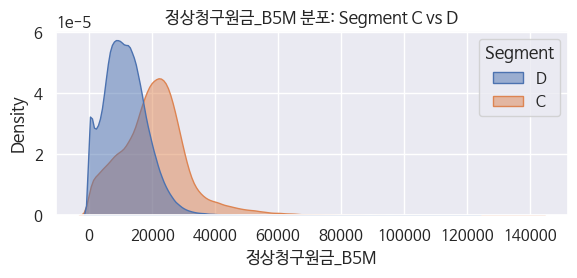

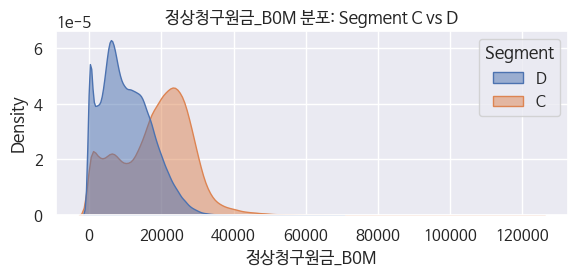

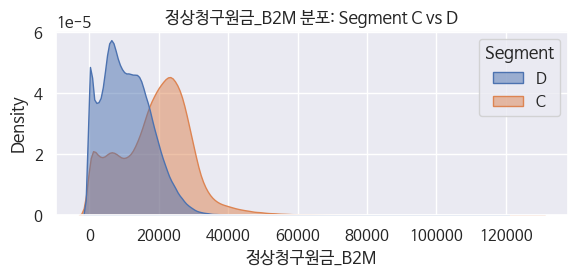

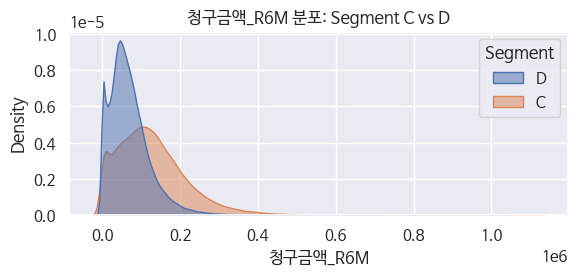

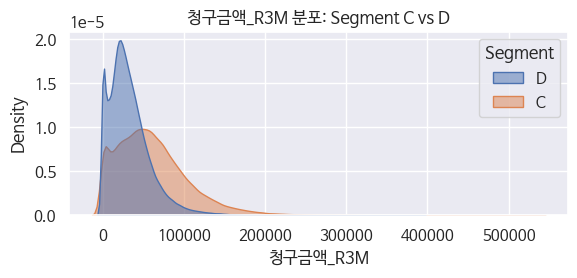

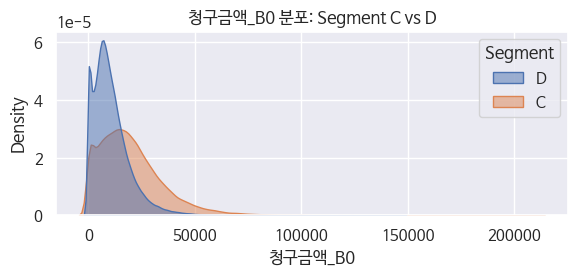

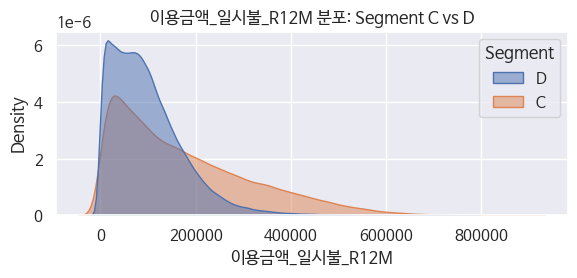

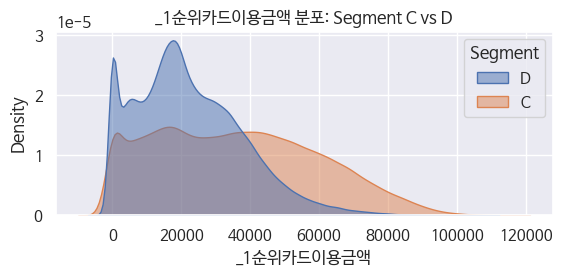

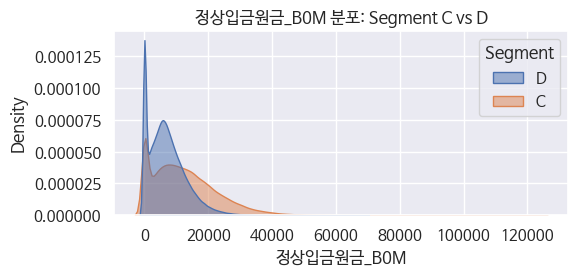

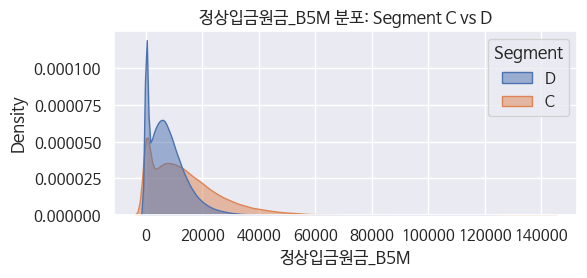

In [19]:
# ① C와 D만 필터링
cd_df = all_df[all_df['Segment'].isin(['C', 'D'])].copy()

# ② D 여부로 바이너리 벡터 생성
cd_df['Segment_binary'] = (cd_df['Segment'] == 'D').astype(int)

# ③ 숫자형 피처만 추출
num_cols = cd_df.select_dtypes(include=['number']).drop(columns=['Segment_binary']).columns

# ④ 각 피처와 D 여부 간 상관계수 계산
correlations = cd_df[num_cols].corrwith(cd_df['Segment_binary'])

# ⑤ 절댓값 기준 상위 10개 피처 추출
top10_features = correlations.abs().sort_values(ascending=False).head(10).index.tolist()

print("C와 D를 가장 잘 나누는 피처 10개:")
print(top10_features)

# ⑥ 시각화
for col in top10_features:
    plt.figure(figsize=(6, 3))
    sns.kdeplot(data=cd_df, x=col, hue='Segment', fill=True, common_norm=False, alpha=0.5)
    plt.title(f'{col} 분포: Segment C vs D')
    plt.tight_layout()
    plt.show()


In [ ]:
for col in ['이용금액_오프라인_R3M', '이용건수_신용_R12M', '연체입금원금_B0M']:
    plt.figure(figsize=(6, 3))
    sns.kdeplot(data=cd_df, x=col, hue='Segment', fill=True)
    plt.title(f'C vs D: {col}')
    plt.show()

두 클래스가 겹치는 정도가 적은 피처일수록 구분에 유리

In [ ]:
categorical_cols = ['이용가능여부_해외겸용_본인', '수신거부여부_TM']

for col in categorical_cols:
    sns.countplot(data=cd_df, x=col, hue='Segment')
    plt.title(f'C vs D by {col}')
    plt.show()


C와 D가 어떤 범주형 값에 치우쳐 있는지 확인